In [1]:
print("hello world")

hello world


# LSTM Gesture Classification — Model Variations

This notebook trains **5 distinct LSTM configurations** for the Data Glove gesture classification project.

| # | Model | Input Dim | Normalization |
|---|-------|-----------|---------------|
| 1 | Raw IMU | 6 | ❌ |
| 2 | Raw IMU | 6 | ✅ |
| 3 | Madgwick Quaternions | 4 | ❌ |
| 4 | Raw + Madgwick | 10 | ❌ |
| 5 | Raw + Madgwick | 10 | ✅ |

In [2]:
import os
import json
import math
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import ahrs

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.8.0+cu128
CUDA available: True


In [3]:
# ============================================================
# CONFIGS — edit these as needed
# ============================================================
import os

# ── MUST be set BEFORE any CUDA operation ──────────────────────
# Forces cuBLAS to use deterministic workspace for GEMM (matrix
# multiply), which LSTM uses internally on GPU.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "42"

DATA_PATH     = "Database/img/"
MODELS_DIR    = "models/"
SEQ_LEN       = 300        # 3 s @ 10 ms = 300 steps
BATCH_SIZE    = 32
HIDDEN_DIM    = 128
NUM_LAYERS    = 1
DROPOUT       = 0.0
EPOCHS        = 90
LR            = 1e-3
TEST_SIZE     = 0.2
RANDOM_STATE  = 42

# MPU6050 raw‑ADC scaling (change if your FS config differs)
ACCEL_SCALE   = 16384.0    # ±2 g
GYRO_SCALE    = 131.0      # ±250 °/s
SAMPLE_RATE   = 100.0      # Hz  (10 ms period)

os.makedirs(MODELS_DIR, exist_ok=True)
print("Config loaded. Models will be saved to:", MODELS_DIR)
print(f"CUBLAS_WORKSPACE_CONFIG = {os.environ['CUBLAS_WORKSPACE_CONFIG']}")
print(f"PYTHONHASHSEED          = {os.environ['PYTHONHASHSEED']}")

Config loaded. Models will be saved to: models/
CUBLAS_WORKSPACE_CONFIG = :4096:8
PYTHONHASHSEED          = 42


In [4]:
# ============================================================
# REPRODUCIBILITY — seed everything + force deterministic ops
# ============================================================
import random

SEED = RANDOM_STATE  # 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# THE KEY CALL — forces ALL PyTorch ops (LSTM, matmul, scatter,
# index_add, etc.) to use deterministic implementations. If any
# op doesn't have one, it raises an error instead of silently
# being non-deterministic.
torch.use_deterministic_algorithms(True)

print(f"✓ Global seeds set to {SEED}")
print(f"✓ torch.use_deterministic_algorithms: {torch.are_deterministic_algorithms_enabled()}")
print(f"✓ cudnn.deterministic: {torch.backends.cudnn.deterministic}")
print(f"✓ cudnn.benchmark:     {torch.backends.cudnn.benchmark}")

✓ Global seeds set to 42
✓ torch.use_deterministic_algorithms: True
✓ cudnn.deterministic: True
✓ cudnn.benchmark:     False


## Madgwick Filter — Quaternion Mathematics

### What is a Quaternion?

A **quaternion** is a 4‑dimensional hyper‑complex number used to represent 3‑D rotations without gimbal lock:

$$q = q_0 + q_1\,\mathbf{i} + q_2\,\mathbf{j} + q_3\,\mathbf{k}$$

where $q_0$ is the scalar (real) part and $(q_1, q_2, q_3)$ is the vector (imaginary) part.  
A **unit quaternion** satisfies $\|q\| = \sqrt{q_0^2 + q_1^2 + q_2^2 + q_3^2} = 1$.

### Quaternion Multiplication (Hamilton Product)

Given two quaternions $p$ and $r$:

$$
p \otimes r = \begin{bmatrix}
p_0 r_0 - p_1 r_1 - p_2 r_2 - p_3 r_3 \\
p_0 r_1 + p_1 r_0 + p_2 r_3 - p_3 r_2 \\
p_0 r_2 - p_1 r_3 + p_2 r_0 + p_3 r_1 \\
p_0 r_3 + p_1 r_2 - p_2 r_1 + p_3 r_0
\end{bmatrix}
$$

### Madgwick Filter Update Equations

**Step 1 — Gyroscope integration (orientation rate):**

$$\dot{q}_{\omega,t} = \tfrac{1}{2}\, q_{t-1} \otimes \begin{bmatrix} 0 \\ \omega_x \\ \omega_y \\ \omega_z \end{bmatrix}$$

**Step 2 — Objective function from accelerometer:**

The accelerometer measures the gravity vector in the sensor frame. The objective function quantifies the error between the measured acceleration $\hat{a}$ and the expected gravity direction rotated by $q$:

$$f(q, \hat{a}) = q^* \otimes \begin{bmatrix} 0\\0\\0\\1 \end{bmatrix} \otimes q - \hat{a}$$

Expanded:

$$f(q, \hat{a}) = \begin{bmatrix}
2(q_1 q_3 - q_0 q_2) - a_x \\
2(q_0 q_1 + q_2 q_3) - a_y \\
2(\tfrac{1}{2} - q_1^2 - q_2^2) - a_z
\end{bmatrix}$$

**Step 3 — Jacobian:**

$$J(q) = \begin{bmatrix}
-2q_2 & 2q_3 & -2q_0 & 2q_1 \\
 2q_1 & 2q_0 &  2q_3 & 2q_2 \\
 0    & -4q_1 & -4q_2 & 0
\end{bmatrix}$$

**Step 4 — Gradient descent correction:**

$$\nabla f = J^T \cdot f$$

**Step 5 — Fuse gyroscope and accelerometer:**

$$q_t = q_{t-1} + \left( \dot{q}_{\omega,t} - \beta \frac{\nabla f}{\|\nabla f\|} \right) \Delta t$$

where $\beta$ is the filter gain representing the estimated gyroscope measurement error,  
and $\Delta t = 1 / f_s = 0.01\,\text{s}$ for our 100 Hz sampling rate.

The result is normalised to maintain $\|q_t\| = 1$.

## Data Loading & Preprocessing

In [5]:
def load_and_preprocess_data():
    """Load CSV files, scale raw ADC values, compute Madgwick quaternions.
    
    Returns
    -------
    X_raw  : np.ndarray  [N, SEQ_LEN, 6]  — scaled accel (m/s²) + gyro (rad/s)
    X_madg : np.ndarray  [N, SEQ_LEN, 4]  — quaternions (q0, q1, q2, q3)
    y      : np.ndarray  [N]               — integer labels
    label_to_idx : dict
    """
    raw_sequences = []
    madg_sequences = []
    labels = []

    madgwick = ahrs.filters.Madgwick(frequency=SAMPLE_RATE)

    for filename in sorted(os.listdir(DATA_PATH)):
        if not filename.endswith('.csv'):
            continue

        path = os.path.join(DATA_PATH, filename)
        df = pd.read_csv(path, header=None, dtype=str)

        # Clean non‑numeric characters, convert
        df = df.astype(str).apply(
            lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x)
        )
        df = df.replace(r'[^\d\.-]', '', regex=True)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.dropna()

        # Pad / truncate to SEQ_LEN
        if df.shape[0] >= SEQ_LEN:
            df = df.iloc[:SEQ_LEN]
        else:
            pad = pd.DataFrame(
                np.zeros((SEQ_LEN - df.shape[0], df.shape[1]))
            )
            df = pd.concat([df, pad], ignore_index=True)

        raw = df.values.astype(np.float64)  # [300, 6]

        # --- Scale to SI units ---
        accel_g    = raw[:, 0:3] / ACCEL_SCALE          # in g
        accel_ms2  = accel_g * 9.80665                   # m/s²
        gyro_dps   = raw[:, 3:6] / GYRO_SCALE           # °/s
        gyro_rads  = np.deg2rad(gyro_dps)                # rad/s

        raw_scaled = np.concatenate([accel_ms2, gyro_rads], axis=1)  # [300, 6]
        raw_sequences.append(raw_scaled)

        # --- Madgwick quaternions ---
        Q = np.zeros((SEQ_LEN, 4), dtype=np.float64)
        Q[0] = [1.0, 0.0, 0.0, 0.0]
        for t in range(1, SEQ_LEN):
            Q[t] = madgwick.updateIMU(Q[t - 1], gyr=gyro_rads[t], acc=accel_g[t])

        madg_sequences.append(Q.astype(np.float32))
        labels.append(filename.split('_')[0])

    label_to_idx = {lbl: idx for idx, lbl in enumerate(sorted(set(labels)))}
    y_indices = np.array([label_to_idx[lbl] for lbl in labels])

    X_raw  = np.stack(raw_sequences)   # [N, 300, 6]
    X_madg = np.stack(madg_sequences)   # [N, 300, 4]

    return X_raw, X_madg, y_indices, label_to_idx


print("Loading dataset …")
X_raw, X_madg, y, label_to_idx = load_and_preprocess_data()
idx_to_label = {v: k for k, v in label_to_idx.items()}

print(f"\nSamples loaded : {len(y)}")
print(f"Classes        : {label_to_idx}")
print(f"X_raw  shape   : {X_raw.shape}")
print(f"X_madg shape   : {X_madg.shape}")
print(f"y      shape   : {y.shape}")

Loading dataset …



Samples loaded : 106
Classes        : {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
X_raw  shape   : (106, 300, 6)
X_madg shape   : (106, 300, 4)
y      shape   : (106,)


## Model Definition & Training Pipeline

In [6]:
# ────────────────────────────────────────────────────────────────
# LSTM Classifier
# ────────────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,
                 num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1])  # last layer hidden state


# ────────────────────────────────────────────────────────────────
# Dataset helper
# ────────────────────────────────────────────────────────────────
class GestureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
def train_and_evaluate(X, y, input_dim, model_name, normalize=False):
    """
    Full training + evaluation pipeline.

    Seeds are reset at the start of EVERY call so each model
    (h1–h5) begins from an identical random state, producing
    bit-for-bit identical results across kernel restarts.

    Saves:
      - models/<model_name>.pth
      - models/<model_name>_metrics.json
    """
    # ── RE-SEED everything so this model starts from a clean slate ────
    import random as _rng
    SEED = RANDOM_STATE  # 42
    _rng.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    # Dedicated Generator for DataLoader shuffle reproducibility
    g = torch.Generator()
    g.manual_seed(SEED)
    # ─────────────────────────────────────────────────────────────────

    print(f"\n{'=' * 60}")
    print(f"  MODEL: {model_name}  (seed={SEED})")
    print(f"  Normalize: {normalize}  |  Input dim: {input_dim}")
    print(f"{'=' * 60}")
    print(f"  X shape : {X.shape}")
    print(f"  y shape : {y.shape}")

    # ── Split ──────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
    )

    # ── Normalize (per‑feature, fit on train only) ─────────────
    if normalize:
        mu  = X_train.mean(axis=(0, 1), keepdims=True)
        std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
        X_train = (X_train - mu) / std
        X_test  = (X_test  - mu) / std
        print(f"  Norm μ  : {mu.squeeze()}")
        print(f"  Norm σ  : {std.squeeze()}")

    print(f"  X_train : {X_train.shape}  |  X_test : {X_test.shape}")
    print()

    # ── Loaders ────────────────────────────────────────────────
    train_loader = DataLoader(
        GestureDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=g,           # ← deterministic shuffle order
    )
    test_loader = DataLoader(
        GestureDataset(X_test, y_test),
        batch_size=BATCH_SIZE,
    )

    # ── Model ──────────────────────────────────────────────────
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(label_to_idx)
    model = LSTMClassifier(
        input_dim, HIDDEN_DIM, num_classes,
        num_layers=NUM_LAYERS, dropout=DROPOUT,
    ).to(device)

    print(f"  Device  : {device}")
    print(f"  Params  : {sum(p.numel() for p in model.parameters()):,}")
    print()

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    # ── Training loop ──────────────────────────────────────────
    history = {
        "train_loss": [], "test_loss": [],
        "train_acc":  [], "test_acc":  [],
        "test_f1":    [],
    }

    for epoch in range(1, EPOCHS + 1):
        # --- train ---
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            out  = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            correct  += (out.argmax(1) == by).sum().item()
            total    += by.size(0)

        train_loss = run_loss / len(train_loader)
        train_acc  = correct / total

        # --- eval ---
        model.eval()
        run_loss_t, correct_t, total_t = 0.0, 0, 0
        all_preds, all_targets = [], []
        with torch.no_grad():
            for bx, by in test_loader:
                bx, by  = bx.to(device), by.to(device)
                out     = model(bx)
                run_loss_t += criterion(out, by).item()
                preds    = out.argmax(1)
                correct_t += (preds == by).sum().item()
                total_t   += by.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(by.cpu().numpy())

        test_loss = run_loss_t / len(test_loader)
        test_acc  = correct_t  / total_t
        f1 = f1_score(all_targets, all_preds, average='weighted')

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["test_f1"].append(f1)

        if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
            print(
                f"  Epoch {epoch:3d}/{EPOCHS}  "
                f"TrainLoss={train_loss:.4f}  TestLoss={test_loss:.4f}  "
                f"TrainAcc={train_acc:.4f}  TestAcc={test_acc:.4f}  "
                f"F1={f1:.4f}"
            )

    # ── Save model & metrics ───────────────────────────────────
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, f"{model_name}.pth"))
    with open(os.path.join(MODELS_DIR, f"{model_name}_metrics.json"), 'w') as fp:
        json.dump(history, fp)

    # ── Final report ───────────────────────────────────────────
    target_names = [idx_to_label[i] for i in range(num_classes)]
    print(f"\n  Final Test Accuracy: {test_acc:.4f}")
    print(f"  Final F1 (weighted): {f1:.4f}")
    print()
    print(classification_report(all_targets, all_preds, target_names=target_names))

    # ── Plots ──────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{model_name}", fontsize=16, fontweight='bold')
    epochs_range = range(1, EPOCHS + 1)

    axes[0, 0].plot(epochs_range, history['train_loss'], label='Train')
    axes[0, 0].plot(epochs_range, history['test_loss'],  label='Test')
    axes[0, 0].set_title('Loss per Epoch')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs_range, history['train_acc'], label='Train')
    axes[0, 1].plot(epochs_range, history['test_acc'],  label='Test')
    axes[0, 1].set_title('Accuracy per Epoch')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(epochs_range, history['test_f1'], color='green', label='Test F1')
    axes[1, 0].set_title('F1 Score (weighted) per Epoch')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    cm = confusion_matrix(all_targets, all_preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=target_names, yticklabels=target_names,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title('Confusion Matrix (final epoch)')
    axes[1, 1].set_xlabel('Predicted')
    axes[1, 1].set_ylabel('True')

    plt.tight_layout()
    plt.show()

    print(f"  ✓ Saved: {MODELS_DIR}{model_name}.pth")
    print(f"  ✓ Saved: {MODELS_DIR}{model_name}_metrics.json")

    return history

## Wrapper Functions

In [8]:
def train_6_input_model(X_raw, y, normalize=False):
    """Train LSTM on the 6 raw IMU channels.
    
    Use Cases:
      normalize=False → Model 1 (6 raw)
      normalize=True  → Model 2 (6 norm)
    """
    name = "model_2_6_norm" if normalize else "model_1_6_raw"
    return train_and_evaluate(X_raw, y, input_dim=6,
                             model_name=name, normalize=normalize)


def train_4_input_model(X_madg, y, normalize=False):
    """Train LSTM on 4 Madgwick quaternion channels.
    
    Use Case:
      normalize=False → Model 3 (4 madgwick)
    """
    name = "model_3_4_madg"
    return train_and_evaluate(X_madg, y, input_dim=4,
                             model_name=name, normalize=normalize)


def train_10_input_model(X_raw, X_madg, y, normalize=False):
    """Train LSTM on 10 channels (6 raw + 4 quaternion).
    
    Use Cases:
      normalize=False → Model 4 (10 raw)
      normalize=True  → Model 5 (10 norm)
    """
    X_concat = np.concatenate([X_raw, X_madg], axis=2)  # [N, 300, 10]
    name = "model_5_10_norm" if normalize else "model_4_10_raw"
    return train_and_evaluate(X_concat, y, input_dim=10,
                             model_name=name, normalize=normalize)

---
## Model 1 — LSTM with 6 Raw Inputs (ax, ay, az, gx, gy, gz)


  MODEL: model_1_6_raw  (seed=42)
  Normalize: False  |  Input dim: 6
  X shape : (106, 300, 6)
  y shape : (106,)
  X_train : (84, 300, 6)  |  X_test : (22, 300, 6)

  Device  : cuda
  Params  : 70,277



  Epoch   1/90  TrainLoss=1.5801  TestLoss=1.5803  TrainAcc=0.3571  TestAcc=0.3636  F1=0.3130
  Epoch  10/90  TrainLoss=0.9391  TestLoss=1.1522  TrainAcc=0.6071  TestAcc=0.5000  F1=0.4970


  Epoch  20/90  TrainLoss=0.4579  TestLoss=0.8712  TrainAcc=0.7738  TestAcc=0.6364  F1=0.6272
  Epoch  30/90  TrainLoss=0.2184  TestLoss=0.6702  TrainAcc=0.9167  TestAcc=0.7727  F1=0.7614


  Epoch  40/90  TrainLoss=0.2976  TestLoss=0.7421  TrainAcc=0.8810  TestAcc=0.7273  F1=0.7116
  Epoch  50/90  TrainLoss=0.1198  TestLoss=0.7000  TrainAcc=0.9643  TestAcc=0.7727  F1=0.7692


  Epoch  60/90  TrainLoss=0.0509  TestLoss=0.7198  TrainAcc=0.9881  TestAcc=0.7727  F1=0.7692
  Epoch  70/90  TrainLoss=0.0181  TestLoss=0.6945  TrainAcc=1.0000  TestAcc=0.7727  F1=0.7692


  Epoch  80/90  TrainLoss=0.0105  TestLoss=0.6891  TrainAcc=1.0000  TestAcc=0.7727  F1=0.7692
  Epoch  90/90  TrainLoss=0.0073  TestLoss=0.6937  TrainAcc=1.0000  TestAcc=0.7727  F1=0.7692

  Final Test Accuracy: 0.7727
  Final F1 (weighted): 0.7692

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       0.67      0.50      0.57         4
           C       0.75      0.75      0.75         4
           D       0.80      0.80      0.80         5
           E       0.67      0.80      0.73         5

    accuracy                           0.77        22
   macro avg       0.78      0.77      0.77        22
weighted avg       0.77      0.77      0.77        22



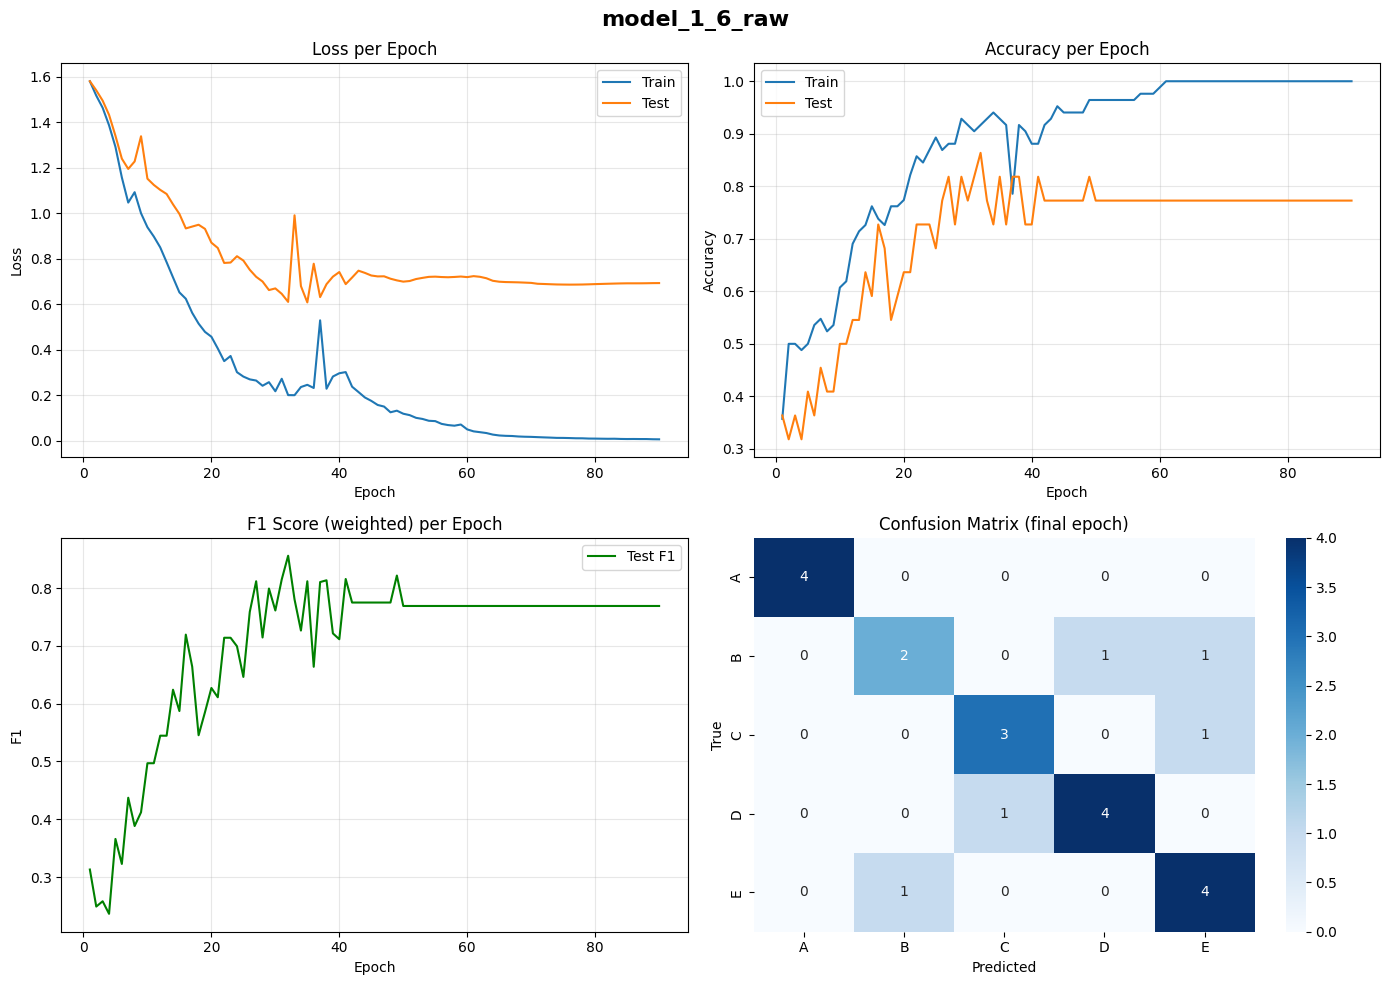

  ✓ Saved: models/model_1_6_raw.pth
  ✓ Saved: models/model_1_6_raw_metrics.json


In [9]:
h1 = train_6_input_model(X_raw, y, normalize=False)

---
## Model 2 — LSTM with 6 Normalized Inputs


  MODEL: model_2_6_norm  (seed=42)
  Normalize: True  |  Input dim: 6
  X shape : (106, 300, 6)
  y shape : (106,)
  Norm μ  : [ 0.16781993  2.97499943  8.74691697  0.04884228  0.05408454 -0.01732226]
  Norm σ  : [133.25684916   3.85718156   3.49295225   1.61830698   0.9759897
   1.26637098]
  X_train : (84, 300, 6)  |  X_test : (22, 300, 6)

  Device  : cuda
  Params  : 70,277

  Epoch   1/90  TrainLoss=1.5983  TestLoss=1.5892  TrainAcc=0.2024  TestAcc=0.2727  F1=0.1674
  Epoch  10/90  TrainLoss=1.0228  TestLoss=1.1863  TrainAcc=0.5238  TestAcc=0.5000  F1=0.4272


  Epoch  20/90  TrainLoss=0.8745  TestLoss=1.2090  TrainAcc=0.6310  TestAcc=0.4545  F1=0.4475
  Epoch  30/90  TrainLoss=0.7607  TestLoss=1.2387  TrainAcc=0.7262  TestAcc=0.6364  F1=0.6190


  Epoch  40/90  TrainLoss=0.6706  TestLoss=1.1198  TrainAcc=0.6786  TestAcc=0.5909  F1=0.5240
  Epoch  50/90  TrainLoss=0.6150  TestLoss=1.1954  TrainAcc=0.7024  TestAcc=0.5455  F1=0.4879


  Epoch  60/90  TrainLoss=0.5339  TestLoss=1.2124  TrainAcc=0.7143  TestAcc=0.5455  F1=0.4931
  Epoch  70/90  TrainLoss=0.5204  TestLoss=1.1928  TrainAcc=0.7024  TestAcc=0.5000  F1=0.4502


  Epoch  80/90  TrainLoss=0.5121  TestLoss=1.0562  TrainAcc=0.7143  TestAcc=0.6364  F1=0.6100
  Epoch  90/90  TrainLoss=0.4492  TestLoss=0.9870  TrainAcc=0.7976  TestAcc=0.7273  F1=0.7244

  Final Test Accuracy: 0.7273
  Final F1 (weighted): 0.7244

              precision    recall  f1-score   support

           A       0.80      1.00      0.89         4
           B       0.67      0.50      0.57         4
           C       1.00      0.75      0.86         4
           D       0.57      0.80      0.67         5
           E       0.75      0.60      0.67         5

    accuracy                           0.73        22
   macro avg       0.76      0.73      0.73        22
weighted avg       0.75      0.73      0.72        22



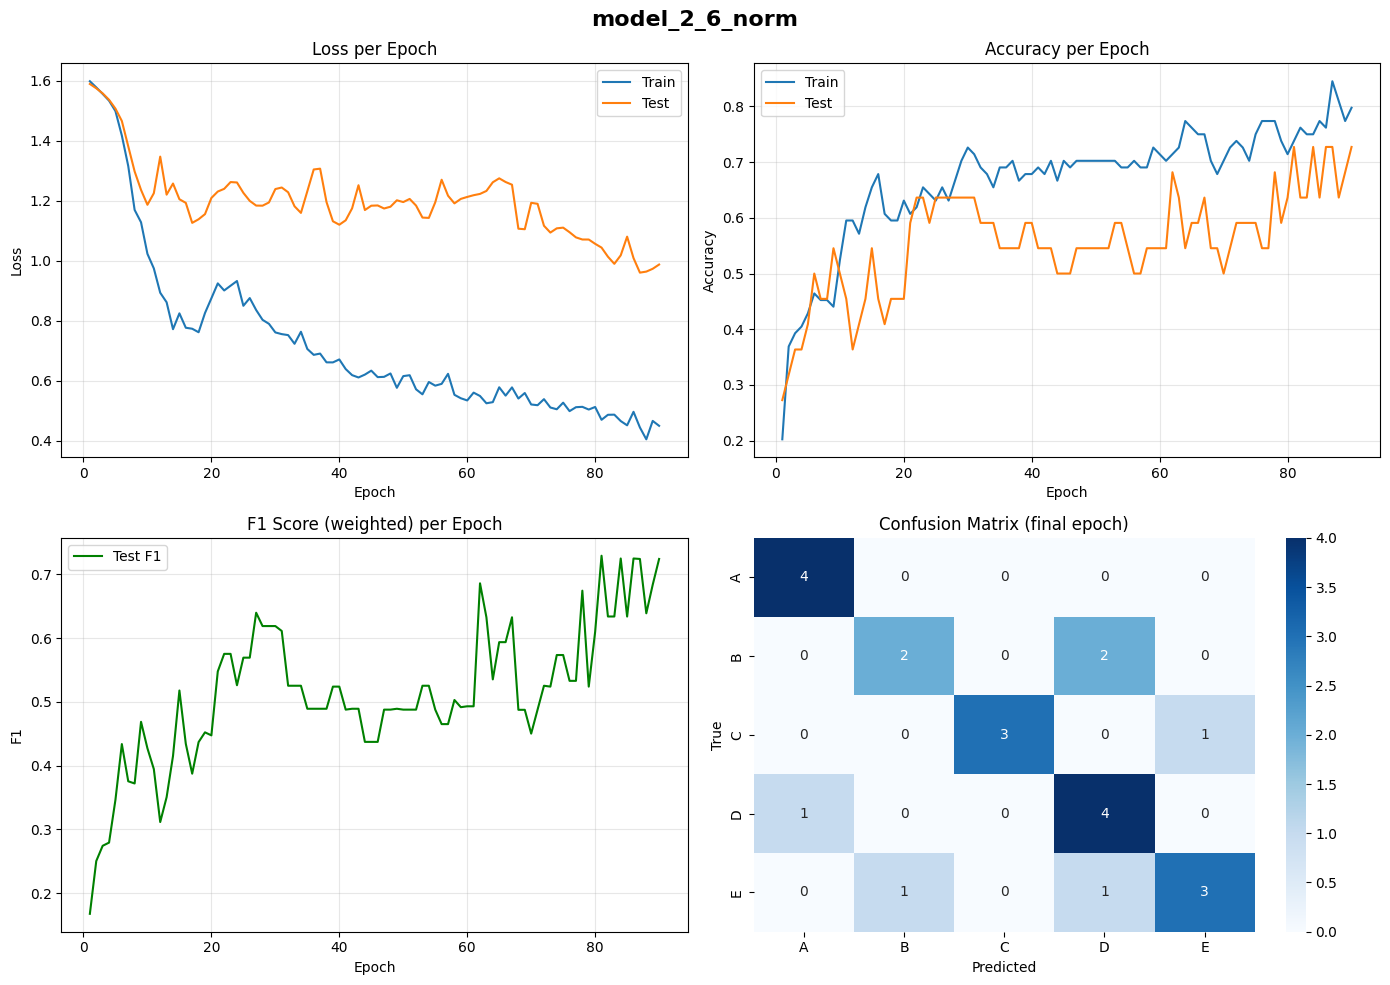

  ✓ Saved: models/model_2_6_norm.pth
  ✓ Saved: models/model_2_6_norm_metrics.json


In [10]:
h2 = train_6_input_model(X_raw, y, normalize=True)

---
## Model 3 — LSTM with 4 Madgwick Quaternion Inputs


  MODEL: model_3_4_madg  (seed=42)
  Normalize: False  |  Input dim: 4
  X shape : (106, 300, 4)
  y shape : (106,)
  X_train : (84, 300, 4)  |  X_test : (22, 300, 4)

  Device  : cuda
  Params  : 69,253

  Epoch   1/90  TrainLoss=1.6100  TestLoss=1.6084  TrainAcc=0.1548  TestAcc=0.1818  F1=0.0559


  Epoch  10/90  TrainLoss=1.5785  TestLoss=1.5827  TrainAcc=0.3095  TestAcc=0.1818  F1=0.0727
  Epoch  20/90  TrainLoss=1.4266  TestLoss=1.5470  TrainAcc=0.3452  TestAcc=0.2727  F1=0.2089


  Epoch  30/90  TrainLoss=1.3537  TestLoss=1.5627  TrainAcc=0.3571  TestAcc=0.2727  F1=0.1984
  Epoch  40/90  TrainLoss=1.3383  TestLoss=1.5431  TrainAcc=0.3810  TestAcc=0.3636  F1=0.2917


  Epoch  50/90  TrainLoss=1.2816  TestLoss=1.4887  TrainAcc=0.3929  TestAcc=0.4091  F1=0.3737
  Epoch  60/90  TrainLoss=1.3743  TestLoss=1.7223  TrainAcc=0.3571  TestAcc=0.3182  F1=0.2545


  Epoch  70/90  TrainLoss=1.4262  TestLoss=1.5049  TrainAcc=0.3214  TestAcc=0.4091  F1=0.3035
  Epoch  80/90  TrainLoss=1.3063  TestLoss=1.5456  TrainAcc=0.4524  TestAcc=0.2727  F1=0.2428


  Epoch  90/90  TrainLoss=1.2745  TestLoss=1.5560  TrainAcc=0.3690  TestAcc=0.3636  F1=0.3042

  Final Test Accuracy: 0.3636
  Final F1 (weighted): 0.3042

              precision    recall  f1-score   support

           A       0.29      0.50      0.36         4
           B       0.33      0.25      0.29         4
           C       0.00      0.00      0.00         4
           D       0.40      0.80      0.53         5
           E       0.50      0.20      0.29         5

    accuracy                           0.36        22
   macro avg       0.30      0.35      0.29        22
weighted avg       0.32      0.36      0.30        22



/home/mush/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mush/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mush/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

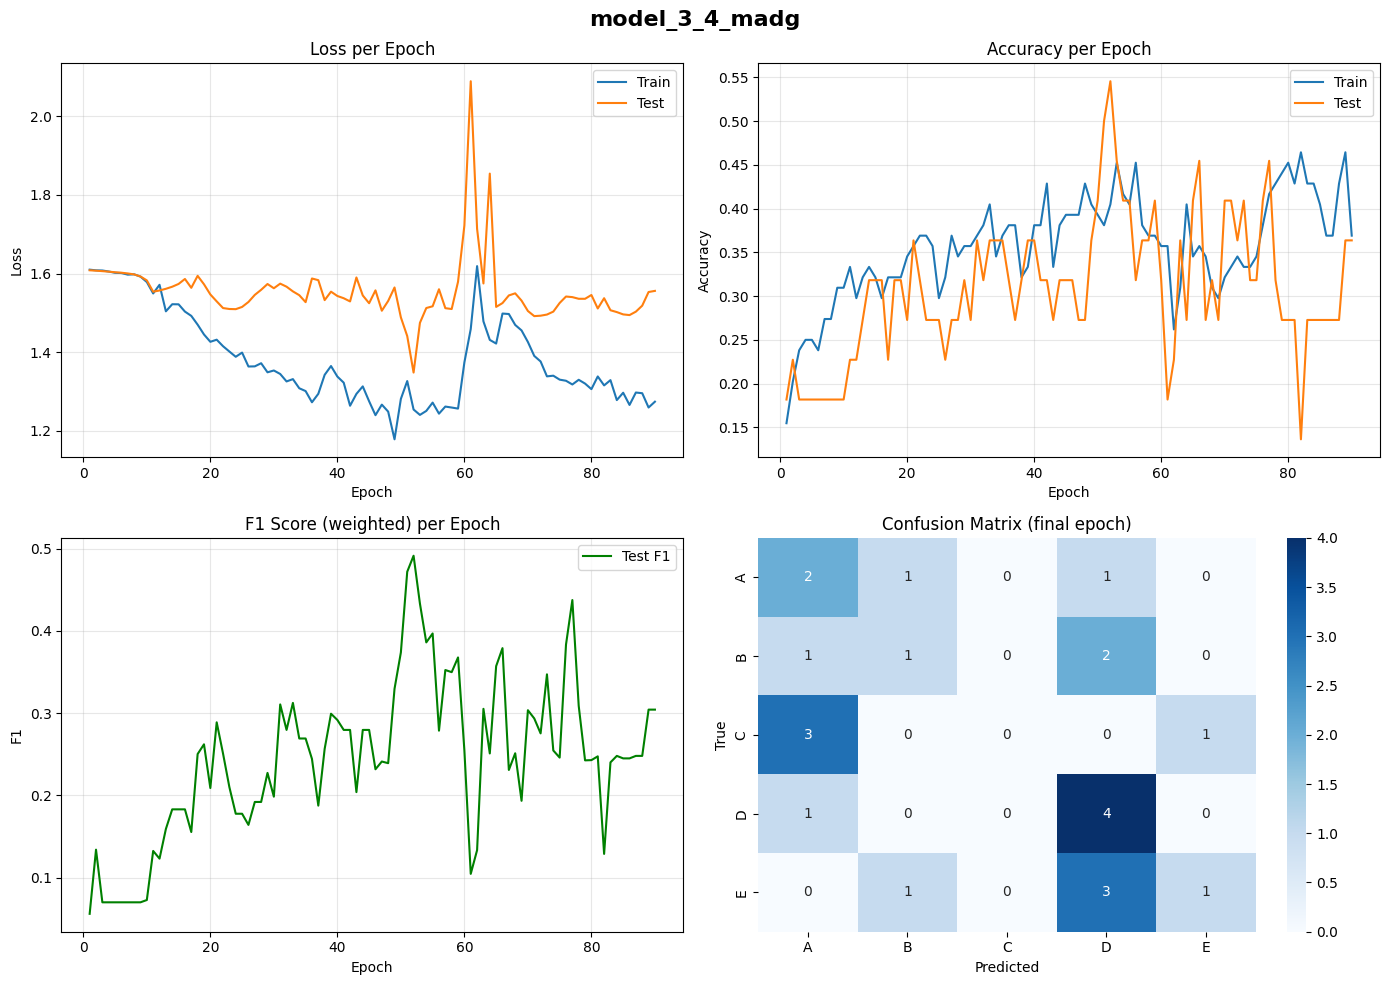

  ✓ Saved: models/model_3_4_madg.pth
  ✓ Saved: models/model_3_4_madg_metrics.json


In [11]:
h3 = train_4_input_model(X_madg, y, normalize=False)

---
## Model 4 — LSTM with 10 Inputs (Raw + Madgwick)


  MODEL: model_4_10_raw  (seed=42)
  Normalize: False  |  Input dim: 10
  X shape : (106, 300, 10)
  y shape : (106,)
  X_train : (84, 300, 10)  |  X_test : (22, 300, 10)

  Device  : cuda
  Params  : 72,325

  Epoch   1/90  TrainLoss=1.6111  TestLoss=1.6069  TrainAcc=0.2857  TestAcc=0.3182  F1=0.2398
  Epoch  10/90  TrainLoss=0.8997  TestLoss=1.1453  TrainAcc=0.6429  TestAcc=0.5455  F1=0.5570


  Epoch  20/90  TrainLoss=0.4322  TestLoss=0.8609  TrainAcc=0.8571  TestAcc=0.6818  F1=0.6751
  Epoch  30/90  TrainLoss=0.1945  TestLoss=0.9725  TrainAcc=0.9524  TestAcc=0.7273  F1=0.7081


  Epoch  40/90  TrainLoss=0.1219  TestLoss=0.9073  TrainAcc=0.9524  TestAcc=0.7727  F1=0.7658
  Epoch  50/90  TrainLoss=0.1777  TestLoss=0.6602  TrainAcc=0.9643  TestAcc=0.8182  F1=0.8106


  Epoch  60/90  TrainLoss=0.0379  TestLoss=0.5722  TrainAcc=1.0000  TestAcc=0.8182  F1=0.8106
  Epoch  70/90  TrainLoss=0.0142  TestLoss=0.6700  TrainAcc=1.0000  TestAcc=0.8182  F1=0.8128


  Epoch  80/90  TrainLoss=0.0139  TestLoss=0.4666  TrainAcc=1.0000  TestAcc=0.8636  F1=0.8601
  Epoch  90/90  TrainLoss=0.0056  TestLoss=0.4732  TrainAcc=1.0000  TestAcc=0.8636  F1=0.8560

  Final Test Accuracy: 0.8636
  Final F1 (weighted): 0.8560

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       0.67      0.50      0.57         4
           C       1.00      1.00      1.00         4
           D       0.80      0.80      0.80         5
           E       0.83      1.00      0.91         5

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.86      0.86      0.86        22



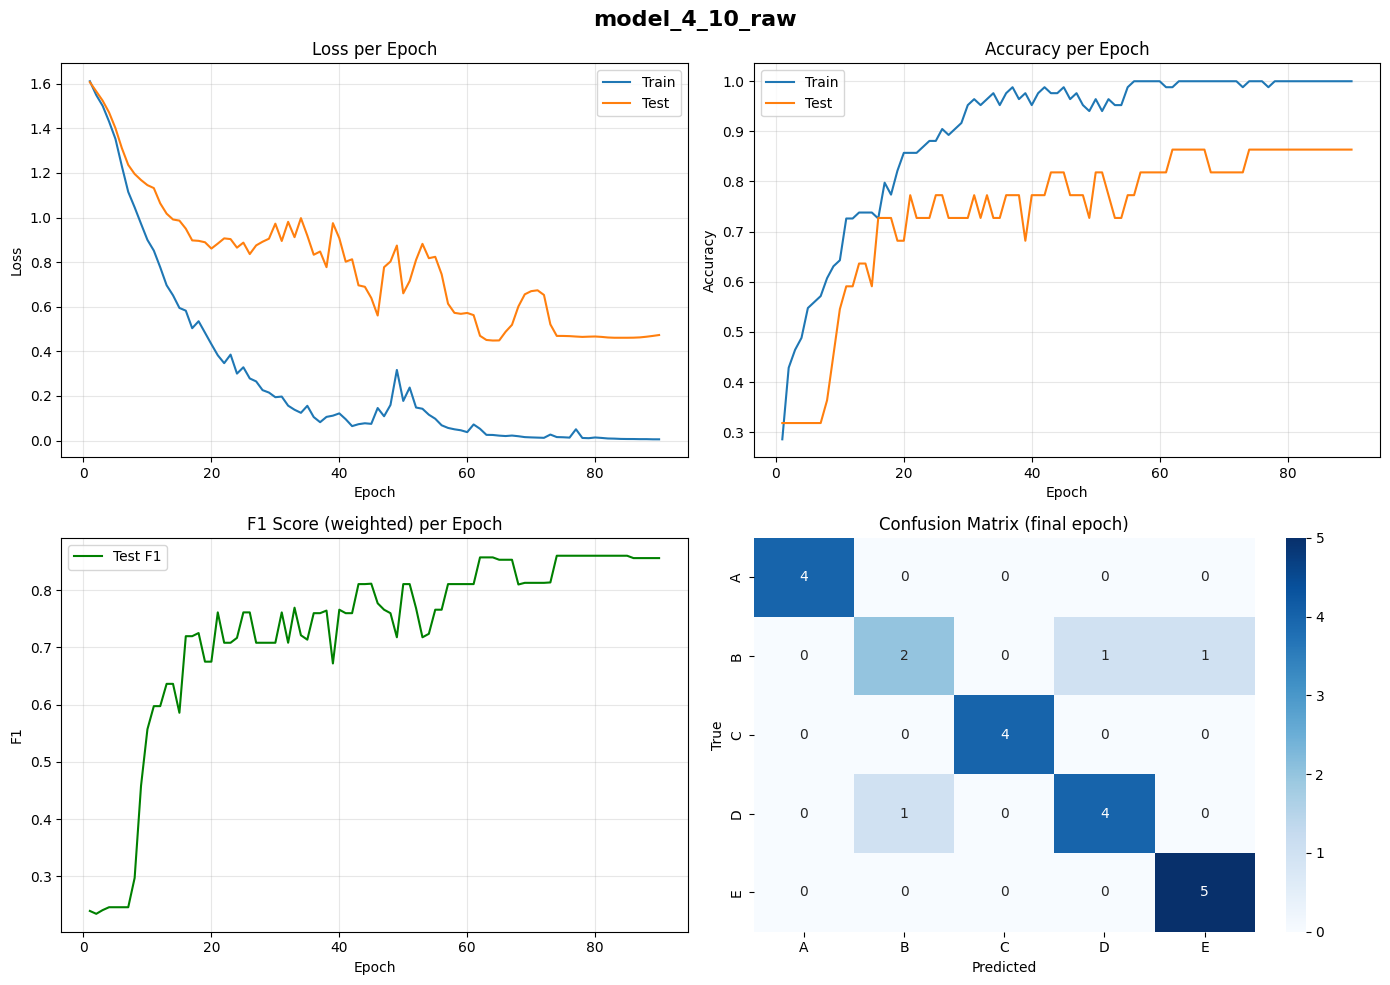

  ✓ Saved: models/model_4_10_raw.pth
  ✓ Saved: models/model_4_10_raw_metrics.json


In [12]:
h4 = train_10_input_model(X_raw, X_madg, y, normalize=False)

---
## Model 5 — LSTM with 10 Normalized Inputs (Raw + Madgwick)


  MODEL: model_5_10_norm  (seed=42)
  Normalize: True  |  Input dim: 10
  X shape : (106, 300, 10)
  y shape : (106,)
  Norm μ  : [ 1.67819926e-01  2.97499943e+00  8.74691697e+00  4.88422767e-02
  5.40845401e-02 -1.73222607e-02  9.84737932e-01 -7.56277586e-04
  2.36921658e-02  1.92624412e-02]
  Norm σ  : [1.33256849e+02 3.85718156e+00 3.49295225e+00 1.61830698e+00
 9.75989701e-01 1.26637098e+00 2.21323649e-02 1.21348206e-01
 7.01780934e-02 9.60108654e-02]
  X_train : (84, 300, 10)  |  X_test : (22, 300, 10)

  Device  : cuda
  Params  : 72,325

  Epoch   1/90  TrainLoss=1.6137  TestLoss=1.6055  TrainAcc=0.1786  TestAcc=0.2273  F1=0.1415


  Epoch  10/90  TrainLoss=1.0221  TestLoss=1.3356  TrainAcc=0.7143  TestAcc=0.5909  F1=0.5740
  Epoch  20/90  TrainLoss=0.5795  TestLoss=0.9359  TrainAcc=0.7143  TestAcc=0.7727  F1=0.7643


  Epoch  30/90  TrainLoss=0.4146  TestLoss=1.0211  TrainAcc=0.8571  TestAcc=0.7273  F1=0.7271
  Epoch  40/90  TrainLoss=0.4950  TestLoss=0.9132  TrainAcc=0.8214  TestAcc=0.6364  F1=0.6425


  Epoch  50/90  TrainLoss=0.4391  TestLoss=1.0922  TrainAcc=0.8571  TestAcc=0.6818  F1=0.6797
  Epoch  60/90  TrainLoss=0.2181  TestLoss=0.9177  TrainAcc=0.9286  TestAcc=0.7273  F1=0.7271


  Epoch  70/90  TrainLoss=0.1561  TestLoss=1.0775  TrainAcc=0.9643  TestAcc=0.7273  F1=0.7271
  Epoch  80/90  TrainLoss=0.1048  TestLoss=1.1947  TrainAcc=0.9762  TestAcc=0.7273  F1=0.7271


  Epoch  90/90  TrainLoss=0.0915  TestLoss=1.2824  TrainAcc=0.9762  TestAcc=0.7273  F1=0.7271

  Final Test Accuracy: 0.7273
  Final F1 (weighted): 0.7271

              precision    recall  f1-score   support

           A       0.80      1.00      0.89         4
           B       0.67      0.50      0.57         4
           C       1.00      0.75      0.86         4
           D       0.50      0.60      0.55         5
           E       0.80      0.80      0.80         5

    accuracy                           0.73        22
   macro avg       0.75      0.73      0.73        22
weighted avg       0.74      0.73      0.73        22



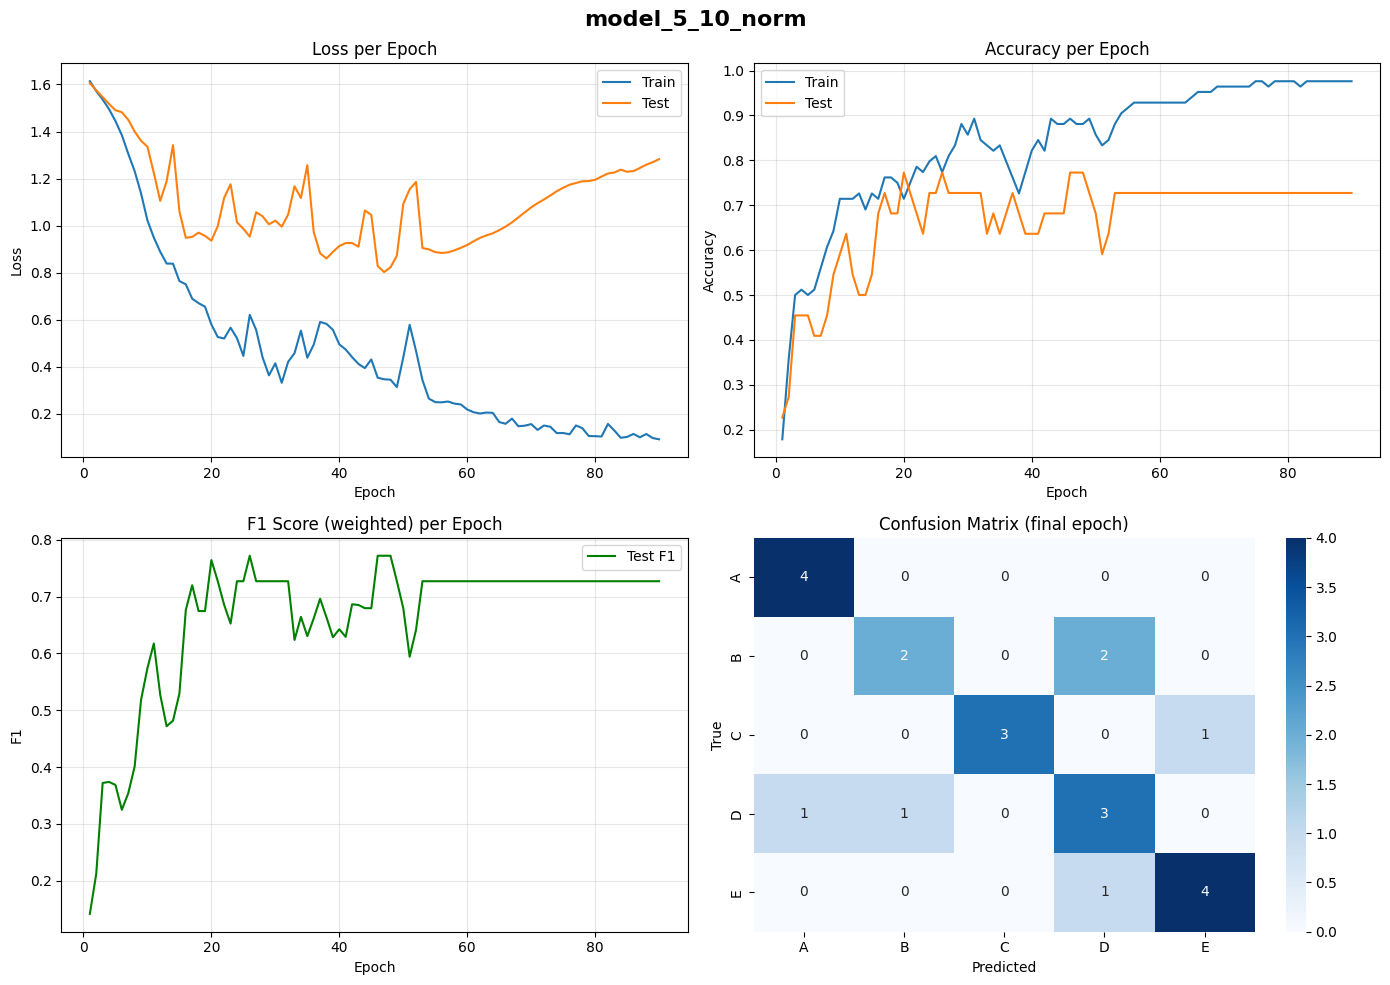

  ✓ Saved: models/model_5_10_norm.pth
  ✓ Saved: models/model_5_10_norm_metrics.json


In [13]:
h5 = train_10_input_model(X_raw, X_madg, y, normalize=True)

---
## Quick Side‑by‑Side Summary

Model               Best Test Acc    Best F1   Final Train Loss
--------------------------------------------------------------
1) 6 Raw                   0.9545     0.9545             0.0608
2) 6 Norm                  0.8636     0.8632             0.2129
3) 4 Madgwick              0.5000     0.4454             1.1144
4) 10 Raw                  0.8636     0.8666             0.0631
5) 10 Norm                 0.9091     0.9067             0.0977


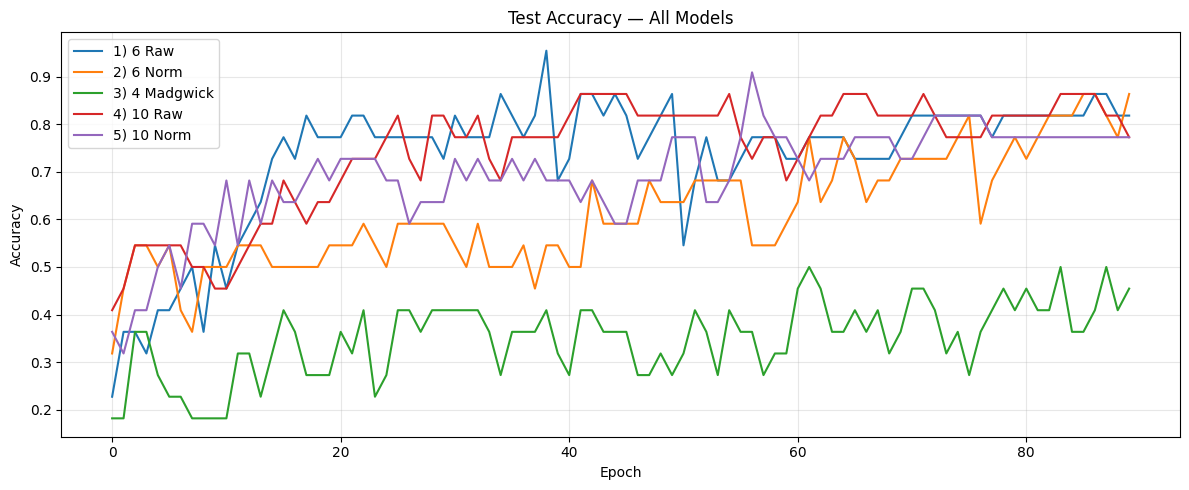


✅ All 5 models trained. Weights and metrics saved to: models/


In [14]:
# Quick summary table
names = [
    "1) 6 Raw",
    "2) 6 Norm",
    "3) 4 Madgwick",
    "4) 10 Raw",
    "5) 10 Norm",
]
histories = [h1, h2, h3, h4, h5]

print(f"{'Model':<18} {'Best Test Acc':>14} {'Best F1':>10} {'Final Train Loss':>18}")
print("-" * 62)
for name, h in zip(names, histories):
    best_acc = max(h['test_acc'])
    best_f1  = max(h['test_f1'])
    final_tl = h['train_loss'][-1]
    print(f"{name:<18} {best_acc:>14.4f} {best_f1:>10.4f} {final_tl:>18.4f}")

# Overlay plot: Test accuracy across all models
plt.figure(figsize=(12, 5))
for name, h in zip(names, histories):
    plt.plot(h['test_acc'], label=name)
plt.title('Test Accuracy — All Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ All 5 models trained. Weights and metrics saved to:", MODELS_DIR)